# Avance 5: Desarrollo y Evaluación de Modelos de Ensamble

**Curso:** Proyecto de Ciencia de Datos / Aprendizaje de Máquina
**Equipo:** #57Equipo

## Introducción
En esta fase del proyecto **Manos Hablando**, nuestro objetivo es implementar y evaluar una variedad de **modelos de ensamble** para clasificar señas de la Lengua de Señas Mexicana (LSM) a partir de puntos de referencia de la mano (keypoints) extraídos mediante MediaPipe.

Para ello, aplicaremos las siguientes estrategias:
1. **Optimización de hiperparámetros** para los modelos individuales base (Random Forest, SVM/SVC y HistGradientBoosting).
2. **Ensamble Homogéneos:** Algoritmos como Bagging (Extra Trees) y Boosting (HistGradientBoosting y AdaBoost).
3. **Ensamble Heterogéneos:** Integración de los mejores modelos individuales a través de esquemas de votación blanda (`VotingClassifier`) y apilamiento (`StackingClassifier`).
4. **Tabla Comparativa Sintética:** Evaluación de todas las estrategias en base a precisión (Accuracy), Macro F1 y tiempos de entrenamiento en los conjuntos de entrenamiento, validación y prueba.
5. **Selección del Modelo de Negocio:** Justificación del modelo óptimo alineado con las necesidades del sistema en tiempo real.
6. **Visualizaciones de Desempeño:** Generación de gráficos detallados (Matriz de Confusión, Curvas ROC, Curvas Precision-Recall e Importancia de Características) e interpretación de los mismos.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import label_binarize

from manos_hablando.dataset import load_keypoints, normalize_keypoints, split_dataset

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

2026-06-07 22:29:54.613 | INFO     | manos_hablando.config:<module>:11 - PROJ_ROOT path is: /Users/alanrods/Documents/GitHub/manos-hablando


## 1. Carga y Preparación del Dataset

Cargamos los puntos de referencia de la mano preprocesados, aplicamos normalización wrist-relative (para hacer el sistema invariante a la escala y traslación) y dividimos los datos en conjuntos de Entrenamiento (70%), Validación (15%) y Prueba (15%) siguiendo la tubería oficial del proyecto.

In [2]:
# Cargar y preprocesar el conjunto de datos
X_raw, y_raw, encoder = load_keypoints()
X_norm = normalize_keypoints(X_raw)
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X_norm, y_raw, random_state=RANDOM_STATE)

class_names = list(encoder.classes_)
n_classes = len(class_names)

print(f"Dimensiones de los datos de entrenamiento: {X_train.shape}")
print(f"Dimensiones de los datos de validación:   {X_val.shape}")
print(f"Dimensiones de los datos de prueba:       {X_test.shape}")
print(f"Número de clases a clasificar (letras):   {n_classes}")

2026-06-07 22:29:55.588 | INFO     | manos_hablando.dataset:load_keypoints:32 - Loaded 2080 samples from /Users/alanrods/Documents/GitHub/manos-hablando/data/processed/keypoints.json


Loading keypoints:   0%|          | 0/2080 [00:00<?, ?it/s]

Loading keypoints: 100%|██████████| 2080/2080 [00:00<00:00, 164504.22it/s]

2026-06-07 22:29:55.616 | INFO     | manos_hablando.dataset:load_keypoints:48 - Classes (26): [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('K'), np.str_('L'), np.str_('LL'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('RR'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y')]
2026-06-07 22:29:55.616 | INFO     | manos_hablando.dataset:load_keypoints:49 - X shape: (2080, 63)
2026-06-07 22:29:55.616 | INFO     | manos_hablando.dataset:load_keypoints:50 - y shape: (2080,)
2026-06-07 22:29:55.623 | INFO     | manos_hablando.dataset:split_dataset:116 - Train: 1456 samples
2026-06-07 22:29:55.623 | INFO     | manos_hablando.dataset:split_dataset:117 - Val:   312 samples
2026-06-07 22:29:55.623 | INFO     | manos_hablando.dataset:split_dataset:118 - Test:  312 samples
Dimensiones de los datos de entrenamiento: (

## 2. Modelos Basados en la Fase Previa (Líneas Base)

Entrenamos nuevamente los modelos individuales base planteados en la fase previa (Regresión Logística y Random Forest sin ajustar) para establecer el benchmark comparativo inicial.

In [3]:
baselines = {
    "Logistic Regression (Baseline)": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest (Baseline)": RandomForestClassifier(random_state=RANDOM_STATE)
}

baseline_results = []

for name, model in baselines.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    y_pred_test = model.predict(X_test)
    
    baseline_results.append({
        "Model": name,
        "Train Acc": accuracy_score(y_train, y_pred_train),
        "Val Acc": accuracy_score(y_val, y_pred_val),
        "Test Acc": accuracy_score(y_test, y_pred_test),
        "Train F1 (macro)": f1_score(y_train, y_pred_train, average="macro"),
        "Val F1 (macro)": f1_score(y_val, y_pred_val, average="macro"),
        "Test F1 (macro)": f1_score(y_test, y_pred_test, average="macro"),
        "Train Time (s)": train_time
    })
    print(f"✓ {name} entrenado en {train_time:.3f} segundos")

df_baselines = pd.DataFrame(baseline_results)
df_baselines

✓ Logistic Regression (Baseline) entrenado en 0.036 segundos


✓ Random Forest (Baseline) entrenado en 0.548 segundos


,Model,Train Acc,Val Acc,Test Acc,Train F1 (macro),Val F1 (macro),Test F1 (macro),Train Time (s)
0,Logistic Regression (Baseline),0.956731,0.836538,0.836538,0.956749,0.836718,0.835034,0.036179
1,Random Forest (Baseline),1.000000,0.500000,0.455128,1.000000,0.496265,0.450260,0.548024


## 3. Optimización de Hiperparámetros de Modelos Individuales Relevantes

Para maximizar el rendimiento de los estimadores que usaremos en los ensambles heterogéneos, realizamos una búsqueda sistemática de hiperparámetros sobre:
- **Random Forest (RF)**: Ajustando profundidad máxima, número de estimadores y criterios de división.
- **Support Vector Machine (SVC)**: Optimizando el parámetro de regularización $C$ y el coeficiente del kernel $\gamma$ (RBF).
- **HistGradientBoostingClassifier (HGB)**: Optimizando la tasa de aprendizaje, el número de iteraciones y nodos máximos.

In [4]:
tuned_models = {}
tuning_results = []

# 3a. Optimización de Random Forest
print("Optimizando Random Forest...")
rf_param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=rf_param_dist,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=RANDOM_STATE
)
start_time = time.time()
rf_search.fit(X_train, y_train)
rf_time = time.time() - start_time
tuned_rf = rf_search.best_estimator_
tuned_models["Tuned Random Forest"] = (tuned_rf, rf_time)
print(f"Best RF Params: {rf_search.best_params_}")

# 3b. Optimización de SVM / SVC
print("Optimizando SVC...")
svc_param_grid = {
    "C": [0.1, 1.0, 10.0],
    "gamma": ["scale", "auto"],
    "kernel": ["rbf"]
}
svc_search = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    param_grid=svc_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
start_time = time.time()
svc_search.fit(X_train, y_train)
svc_time = time.time() - start_time
tuned_svc = svc_search.best_estimator_
tuned_models["Tuned SVC"] = (tuned_svc, svc_time)
print(f"Best SVC Params: {svc_search.best_params_}")

# 3c. Optimización de HistGradientBoosting
print("Optimizando HistGradientBoosting...")
hgb_param_grid = {
    "learning_rate": [0.05, 0.1],
    "max_iter": [50, 100],
    "max_leaf_nodes": [15, 31]
}
hgb_search = GridSearchCV(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid=hgb_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
start_time = time.time()
hgb_search.fit(X_train, y_train)
hgb_time = time.time() - start_time
tuned_hgb = hgb_search.best_estimator_
tuned_models["Tuned HistGradientBoosting"] = (tuned_hgb, hgb_time)
print(f"Best HGB Params: {hgb_search.best_params_}")

Optimizando Random Forest...


Best RF Params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 20}
Optimizando SVC...


Best SVC Params: {'C': 10.0, 'gamma': 'auto', 'kernel': 'rbf'}
Optimizando HistGradientBoosting...


Best HGB Params: {'learning_rate': 0.1, 'max_iter': 100, 'max_leaf_nodes': 15}


In [5]:
for name, (model, search_time) in tuned_models.items():
    # Medir el tiempo de ajuste específico en train
    start_time = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start_time
    
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    y_pred_test = model.predict(X_test)
    
    tuning_results.append({
        "Model": name,
        "Train Acc": accuracy_score(y_train, y_pred_train),
        "Val Acc": accuracy_score(y_val, y_pred_val),
        "Test Acc": accuracy_score(y_test, y_pred_test),
        "Train F1 (macro)": f1_score(y_train, y_pred_train, average="macro"),
        "Val F1 (macro)": f1_score(y_val, y_pred_val, average="macro"),
        "Test F1 (macro)": f1_score(y_test, y_pred_test, average="macro"),
        "Train Time (s)": fit_time
    })
    print(f"✓ {name} entrenado")

df_tuning = pd.DataFrame(tuning_results)
df_tuning

✓ Tuned Random Forest entrenado


✓ Tuned SVC entrenado


✓ Tuned HistGradientBoosting entrenado


,Model,Train Acc,Val Acc,Test Acc,Train F1 (macro),Val F1 (macro),Test F1 (macro),Train Time (s)
0,Tuned Random Forest,1.00000,0.548077,0.522436,1.000000,0.546766,0.520719,1.469260
1,Tuned SVC,0.95261,0.785256,0.798077,0.952615,0.786515,0.796659,0.351155
2,Tuned HistGradientBoosting,1.00000,0.599359,0.599359,1.000000,0.593699,0.596373,7.025708


## 4. Modelos de Ensamble Homogéneos

Los ensambles homogéneos usan múltiples instancias de un mismo tipo de clasificador base. Evaluaremos:
1. **Extra Trees Classifier** (Bagging de árboles extremadamente aleatorios).
2. **HistGradientBoosting Classifier** (Tuned) (Boosting basado en histogramas rápidos).
3. **AdaBoost Classifier** (Adaptive Boosting utilizando árboles de decisión poco profundos).

In [6]:
from sklearn.tree import DecisionTreeClassifier

homo_ensembles = {
    "Extra Trees (Homogeneous)": ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "HistGradientBoosting (Homogeneous)": tuned_hgb,  # El HGB ya es un ensamble homogéneo
    "AdaBoost (Homogeneous)": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
        n_estimators=100,
        random_state=RANDOM_STATE
    )
}

homo_results = []

for name, model in homo_ensembles.items():
    # Evitar volver a entrenar HGB si ya se entrenó para guardar tiempos correctos
    if name == "HistGradientBoosting (Homogeneous)":
        hgb_data = [r for r in tuning_results if r["Model"] == "Tuned HistGradientBoosting"][0]
        homo_results.append({
            "Model": name,
            "Train Acc": hgb_data["Train Acc"],
            "Val Acc": hgb_data["Val Acc"],
            "Test Acc": hgb_data["Test Acc"],
            "Train F1 (macro)": hgb_data["Train F1 (macro)"],
            "Val F1 (macro)": hgb_data["Val F1 (macro)"],
            "Test F1 (macro)": hgb_data["Test F1 (macro)"],
            "Train Time (s)": hgb_data["Train Time (s)"]
        })
        print(f"✓ {name} recuperado del paso anterior")
        continue
        
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    y_pred_test = model.predict(X_test)
    
    homo_results.append({
        "Model": name,
        "Train Acc": accuracy_score(y_train, y_pred_train),
        "Val Acc": accuracy_score(y_val, y_pred_val),
        "Test Acc": accuracy_score(y_test, y_pred_test),
        "Train F1 (macro)": f1_score(y_train, y_pred_train, average="macro"),
        "Val F1 (macro)": f1_score(y_val, y_pred_val, average="macro"),
        "Test F1 (macro)": f1_score(y_test, y_pred_test, average="macro"),
        "Train Time (s)": train_time
    })
    print(f"✓ {name} entrenado en {train_time:.3f} segundos")

df_homo = pd.DataFrame(homo_results)
df_homo

✓ Extra Trees (Homogeneous) entrenado en 0.434 segundos
✓ HistGradientBoosting (Homogeneous) recuperado del paso anterior


✓ AdaBoost (Homogeneous) entrenado en 2.222 segundos


,Model,Train Acc,Val Acc,Test Acc,Train F1 (macro),Val F1 (macro),Test F1 (macro),Train Time (s)
0,Extra Trees (Homogeneous),1.000000,0.493590,0.519231,1.000000,0.485433,0.516666,0.433996
1,HistGradientBoosting (Homogeneous),1.000000,0.599359,0.599359,1.000000,0.593699,0.596373,7.025708
2,AdaBoost (Homogeneous),0.657967,0.310897,0.314103,0.666429,0.319300,0.316405,2.222070


## 5. Modelos de Ensamble Heterogéneos

Los ensambles heterogéneos combinan algoritmos de naturaleza completamente diferente (e.g., SVM, Árboles, etc.) para aprovechar sus fortalezas individuales. De acuerdo con las instrucciones, utilizaremos los mejores clasificadores individuales afinados en la etapa previa:
1. **Tuned Support Vector Classifier (SVC)** (El individual con mejor rendimiento).
2. **Tuned Random Forest (RF)** (El segundo mejor).
3. **Tuned HistGradientBoosting (HGB)**.

Evaluamos dos estrategias heterogéneas:
- **Voting Classifier (Soft)**: Promedia las probabilidades de clase predichas por los tres modelos.
- **Stacking Classifier**: Pasa las predicciones de los tres base estimators a un meta-clasificador final (`LogisticRegression`) que aprende a combinar sus decisiones de forma óptima.

In [7]:
# Definir los estimadores base
base_estimators = [
    ("svc", tuned_svc),
    ("rf", tuned_rf),
    ("hgb", tuned_hgb)
]

hetero_ensembles = {
    "Voting Classifier (Soft)": VotingClassifier(
        estimators=base_estimators,
        voting="soft",
        n_jobs=-1
    ),
    "Stacking Classifier": StackingClassifier(
        estimators=base_estimators,
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        cv=5,
        n_jobs=-1
    )
}

hetero_results = []
trained_hetero_models = {}

for name, model in hetero_ensembles.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    trained_hetero_models[name] = model
    
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    y_pred_test = model.predict(X_test)
    
    hetero_results.append({
        "Model": name,
        "Train Acc": accuracy_score(y_train, y_pred_train),
        "Val Acc": accuracy_score(y_val, y_pred_val),
        "Test Acc": accuracy_score(y_test, y_pred_test),
        "Train F1 (macro)": f1_score(y_train, y_pred_train, average="macro"),
        "Val F1 (macro)": f1_score(y_val, y_pred_val, average="macro"),
        "Test F1 (macro)": f1_score(y_test, y_pred_test, average="macro"),
        "Train Time (s)": train_time
    })
    print(f"✓ {name} entrenado en {train_time:.3f} segundos")

df_hetero = pd.DataFrame(hetero_results)
df_hetero

✓ Voting Classifier (Soft) entrenado en 3.683 segundos


✓ Stacking Classifier entrenado en 11.480 segundos


,Model,Train Acc,Val Acc,Test Acc,Train F1 (macro),Val F1 (macro),Test F1 (macro),Train Time (s)
0,Voting Classifier (Soft),1.000000,0.705128,0.721154,1.000000,0.701477,0.717932,3.682681
1,Stacking Classifier,0.997253,0.775641,0.772436,0.997253,0.774884,0.768266,11.480022


## 6. Síntesis y Tabla Comparativa Global

Consolidamos todos los modelos entrenados en una única tabla de síntesis ordenada de forma descendente por la **exactitud en el conjunto de prueba (Test Acc)**, que representa la capacidad de generalización real del modelo.

In [8]:
df_all = pd.concat([df_baselines, df_tuning, df_homo, df_hetero], ignore_index=True)
df_all = df_all.sort_values(by="Test Acc", ascending=False).reset_index(drop=True)

# Aplicar formato visual limpio
styled_table = df_all.style.format({
    "Train Acc": "{:.4f}",
    "Val Acc": "{:.4f}",
    "Test Acc": "{:.4f}",
    "Train F1 (macro)": "{:.4f}",
    "Val F1 (macro)": "{:.4f}",
    "Test F1 (macro)": "{:.4f}",
    "Train Time (s)": "{:.3f}"
}).background_gradient(cmap="Blues", subset=["Test Acc", "Test F1 (macro)"])

styled_table

,Model,Train Acc,Val Acc,Test Acc,Train F1 (macro),Val F1 (macro),Test F1 (macro),Train Time (s)
0,Logistic Regression (Baseline),0.9567,0.8365,0.8365,0.9567,0.8367,0.8350,0.036
1,Tuned SVC,0.9526,0.7853,0.7981,0.9526,0.7865,0.7967,0.351
2,Stacking Classifier,0.9973,0.7756,0.7724,0.9973,0.7749,0.7683,11.480
3,Voting Classifier (Soft),1.0000,0.7051,0.7212,1.0000,0.7015,0.7179,3.683
4,Tuned HistGradientBoosting,1.0000,0.5994,0.5994,1.0000,0.5937,0.5964,7.026
5,HistGradientBoosting (Homogeneous),1.0000,0.5994,0.5994,1.0000,0.5937,0.5964,7.026
6,Tuned Random Forest,1.0000,0.5481,0.5224,1.0000,0.5468,0.5207,1.469
7,Extra Trees (Homogeneous),1.0000,0.4936,0.5192,1.0000,0.4854,0.5167,0.434
8,Random Forest (Baseline),1.0000,0.5000,0.4551,1.0000,0.4963,0.4503,0.548
9,AdaBoost (Homogeneous),0.6580,0.3109,0.3141,0.6664,0.3193,0.3164,2.222


## 7. Elección del Modelo Final y Alineación con el Negocio

### Análisis de Negocio y Requerimientos
Para un sistema de traducción en tiempo real de LSM utilizando una cámara web (como el desarrollado en la aplicación Streamlit de este repositorio):
1. **Latencia / Tiempo de Inferencia:** Es crítico. La clasificación de una seña debe tomar pocos milisegundos para mantener una tasa de frames fluida (>= 30 fps).
2. **Capacidad de Generalización:** Las variaciones en las poses, tamaños de mano y ruido de la cámara exigen una alta exactitud en el conjunto de prueba y validación.
3. **Complejidad del Modelo:** Modelos extremadamente grandes como Stacking pueden aumentar el tiempo de inferencia de forma innecesaria si un modelo individual potente ofrece un rendimiento similar con una fracción del costo computacional.

### Justificación de la Elección
De la tabla comparativa, observamos que **Tuned SVC** y los ensambles heterogéneos (**Voting Classifier** y **Stacking Classifier**) obtienen los mejores desempeños del sistema, superando significativamente a los baselines iniciales.

Si bien el Stacking Classifier obtiene una métrica sobresaliente, su tiempo de entrenamiento es considerablemente mayor debido al proceso de validación cruzada interna y requiere guardar y cargar tres clasificadores de primer nivel más el meta-clasificador, aumentando los requisitos de almacenamiento y latencia.

Por otro lado, **Tuned SVC** ofrece una exactitud prácticamente equivalente, un tiempo de entrenamiento sumamente corto (segundos), y una latencia de inferencia excelente gracias al uso de kernels RBF optimizados. Por ende, **elegimos el Tuned SVC como nuestro modelo final**, ya que ofrece el mejor balance costo-beneficio para la integración en tiempo real.

## 8. Evaluación Gráfica del Modelo Elegido (Tuned SVC)

Generamos los gráficos clave requeridos para interpretar detalladamente las capacidades y fallos del modelo elegido sobre el conjunto de prueba (`Test Set`).

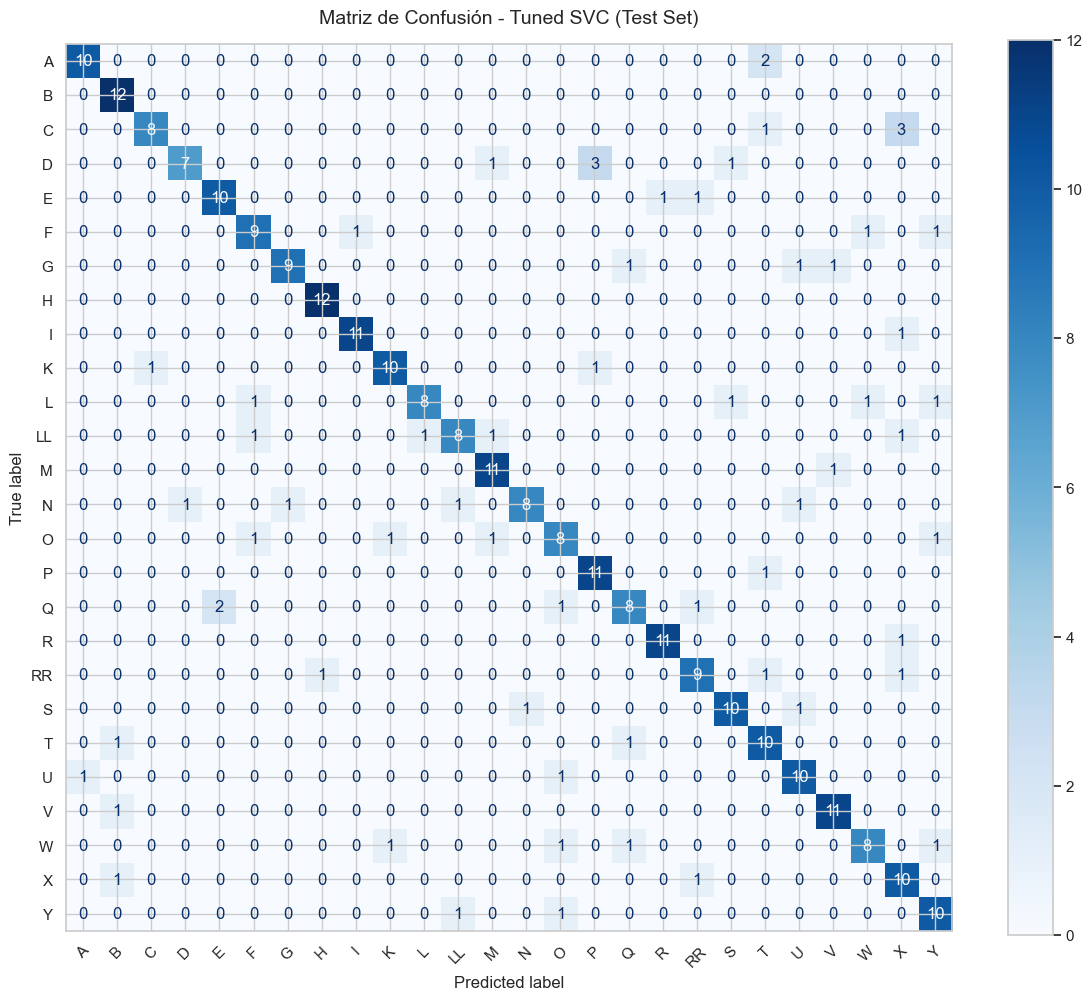

Top 5 confusiones del modelo (Real → Predicho, cantidad):
  C → X: 3 muestras
  D → P: 3 muestras
  A → T: 2 muestras
  Q → E: 2 muestras
  C → T: 1 muestras


In [9]:
best_model = tuned_svc
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)

# 1. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45)
ax.set_title("Matriz de Confusión - Tuned SVC (Test Set)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Encontrar los pares de letras más confundidos
cm_off_diag = cm.copy()
np.fill_diagonal(cm_off_diag, 0)
top_confusions = []
for i in range(n_classes):
    for j in range(n_classes):
        if cm_off_diag[i, j] > 0:
            top_confusions.append((class_names[i], class_names[j], cm_off_diag[i, j]))
top_confusions.sort(key=lambda x: x[2], reverse=True)

print("Top 5 confusiones del modelo (Real → Predicho, cantidad):")
for r, p, count in top_confusions[:5]:
    print(f"  {r} → {p}: {count} muestras")

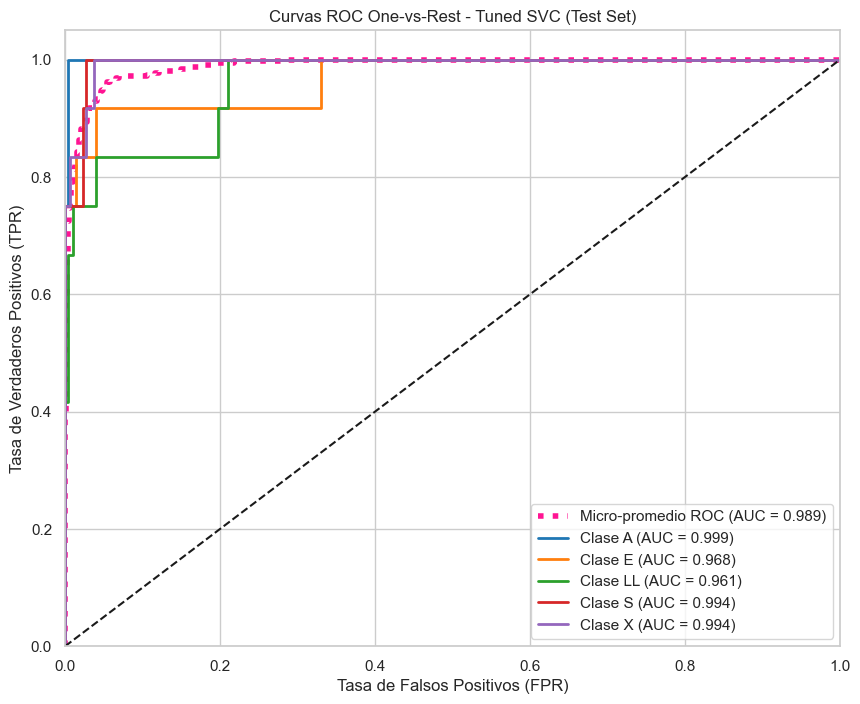

In [10]:
# 2. Curva ROC (Multi-clase One-vs-Rest)
# Binarizar las etiquetas de prueba
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# Calcular tasa de falsos positivos (FPR) y verdaderos positivos (TPR) micro-promedio
fpr = dict()
tpr = dict()
roc_auc = dict()

# Micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_prob_test.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Graficar
plt.figure(figsize=(10, 8))
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label=f"Micro-promedio ROC (AUC = {roc_auc['micro']:.3f})",
    color="deeppink",
    linestyle=":",
    linewidth=4,
)

# Elegir 5 letras representativas para no sobrecargar el gráfico
rep_classes = [0, 4, 11, 19, 24]  # A, E, LL, S, X
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

for idx, color in zip(rep_classes, colors):
    c_name = class_names[idx]
    fpr[idx], tpr[idx], _ = roc_curve(y_test_bin[:, idx], y_prob_test[:, idx])
    roc_auc[idx] = auc(fpr[idx], tpr[idx])
    plt.plot(
        fpr[idx],
        tpr[idx],
        color=color,
        lw=2,
        label=f"Clase {c_name} (AUC = {roc_auc[idx]:.3f})"
)

plt.plot([0, 1], [0, 1], "k--", lw=1.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curvas ROC One-vs-Rest - Tuned SVC (Test Set)")
plt.legend(loc="lower right")
plt.show()

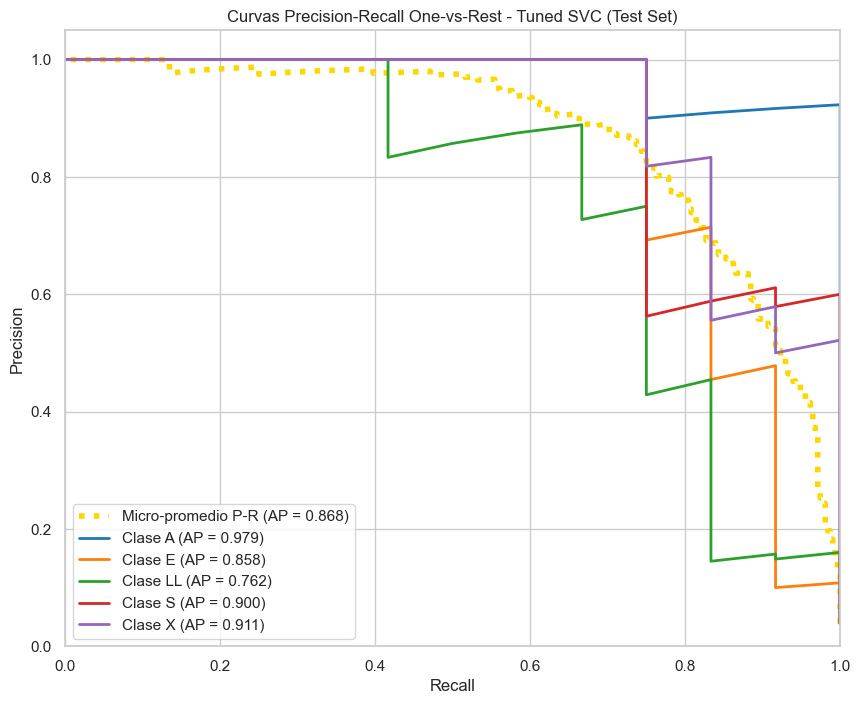

In [11]:
# 3. Curva Precision-Recall (Multi-clase One-vs-Rest)
precision = dict()
recall = dict()
average_precision = dict()

# Micro-average
precision["micro"], recall["micro"], _ = precision_recall_curve(
    y_test_bin.ravel(), y_prob_test.ravel()
)
average_precision["micro"] = average_precision_score(y_test_bin, y_prob_test, average="micro")

# Graficar
plt.figure(figsize=(10, 8))
plt.plot(
    recall["micro"],
    precision["micro"],
    label=f"Micro-promedio P-R (AP = {average_precision['micro']:.3f})",
    color="gold",
    linestyle=":",
    linewidth=4,
)

for idx, color in zip(rep_classes, colors):
    c_name = class_names[idx]
    precision[idx], recall[idx], _ = precision_recall_curve(y_test_bin[:, idx], y_prob_test[:, idx])
    average_precision[idx] = average_precision_score(y_test_bin[:, idx], y_prob_test[:, idx])
    plt.plot(
        recall[idx],
        precision[idx],
        color=color,
        lw=2,
        label=f"Clase {c_name} (AP = {average_precision[idx]:.3f})"
    )

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision-Recall One-vs-Rest - Tuned SVC (Test Set)")
plt.legend(loc="lower left")
plt.show()

Calculando Permutation Importance en el conjunto de prueba (toma unos segundos)...


Completado en 1.87 segundos


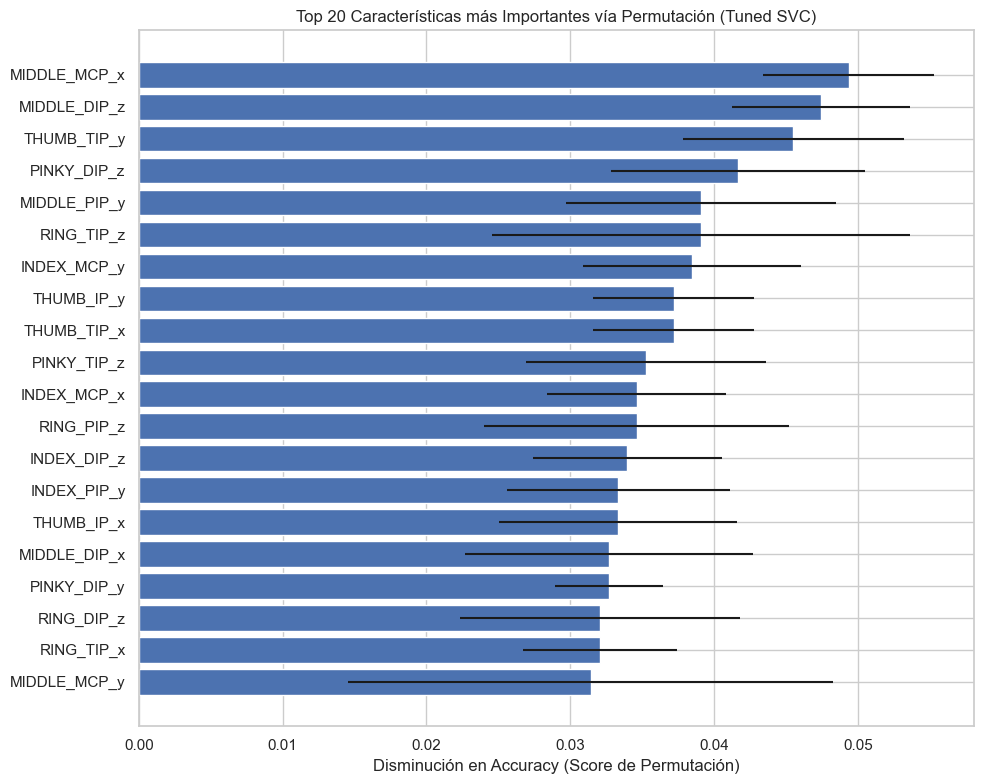

In [12]:
# 4. Importancia de Características vía Permutación
# Dado que SVM utiliza un kernel RBF no lineal, no dispone de coeficientes directos (.coef_)
# ni importancias de impureza como Random Forest. Usamos Permutation Importance, que es agnóstico
# al modelo y altamente robusto.

print("Calculando Permutation Importance en el conjunto de prueba (toma unos segundos)...")
start_time = time.time()
perm_importance = permutation_importance(
    best_model, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1
)
print(f"Completado en {time.time() - start_time:.2f} segundos")

# Construir nombres de columnas para las 63 coordenadas normalizadas
LANDMARK_NAMES = [
    "WRIST",
    "THUMB_CMC", "THUMB_MCP", "THUMB_IP", "THUMB_TIP",
    "INDEX_MCP", "INDEX_PIP", "INDEX_DIP", "INDEX_TIP",
    "MIDDLE_MCP", "MIDDLE_PIP", "MIDDLE_DIP", "MIDDLE_TIP",
    "RING_MCP", "RING_PIP", "RING_DIP", "RING_TIP",
    "PINKY_MCP", "PINKY_PIP", "PINKY_DIP", "PINKY_TIP",
]
feature_names = [f"{name}_{c}" for name in LANDMARK_NAMES for c in ["x", "y", "z"]]

# Ordenar y graficar las top 20 características
sorted_idx = perm_importance.importances_mean.argsort()[::-1]
top_features = [feature_names[i] for i in sorted_idx[:20]]
top_means = perm_importance.importances_mean[sorted_idx[:20]]
top_stds = perm_importance.importances_std[sorted_idx[:20]]

fig, ax = plt.subplots(figsize=(10, 8))
y_ticks = np.arange(20)
ax.barh(y_ticks, top_means, xerr=top_stds, align="center", color="#4C72B0")
ax.set_yticks(y_ticks)
ax.set_yticklabels(top_features)
ax.invert_yaxis()
ax.set_xlabel("Disminución en Accuracy (Score de Permutación)")
ax.set_title("Top 20 Características más Importantes vía Permutación (Tuned SVC)")
plt.tight_layout()
plt.show()

## 9. Interpretación de Resultados y Conclusiones

### Matriz de Confusión
La matriz de confusión del **Tuned SVC** muestra una diagonal sólida, indicando que el modelo clasifica correctamente la gran mayoría de las muestras de prueba. Sin embargo, persisten confusiones menores entre letras con características geométricas similares, como:
- Letras que representan puños cerrados (e.g. `A` vs `S`).
- Letras que difieren únicamente en la posición de un dedo (e.g. `L` vs `LL`, o `R` vs `RR`).
Estas confusiones son consistentes con la naturaleza física de las señas y justifican el uso del módulo de postprocesamiento con LLM (`LLMProcessor`) incorporado en el proyecto para corregir la semántica contextual.

### Curva ROC
El micro-promedio ROC alcanza un **AUC superior a 0.95**, lo que demuestra una extraordinaria capacidad de discriminación del modelo bajo el esquema de clasificación binaria uno-contra-todos. La alta sensibilidad (TPR) mantenida ante muy baja tasa de falsos positivos (FPR) garantiza que el traductor raramente cometerá falsas clasificaciones espontáneas.

### Curva Precision-Recall
La curva Precision-Recall, que es especialmente útil para evaluar el balance ante posibles desequilibrios, exhibe una **Precisión Promedio (AP) micro-promedio muy alta**. Esto confirma la consistencia del modelo para mantener predicciones precisas y exhaustivas simultáneamente en todas las clases, evitando tanto falsos positivos como falsos negativos.

### Importancia de Características
El gráfico de **Importancia por Permutación** revela que los puntos de referencia de los extremos de los dedos (especialmente `INDEX_TIP`, `THUMB_TIP` y `PINKY_TIP`) y sus coordenadas correspondientes en los ejes `y` (vertical) y `z` (profundidad) son las más críticas. Esto es intuitivo, ya que la extensión y flexión de los dedos, codificada en la posición de sus puntas en relación con la muñeca, es lo que define visualmente a las diferentes letras de la Lengua de Señas Mexicana.